In [1]:
import os
import sys
import json
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import librosa
import librosa.display
import soundfile as sf

# Set Root Repositori
NOTEBOOK_DIR = Path(os.getcwd())
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_DIR = REPO_ROOT / "data" / "BirdClef"
MANIFEST_DIR = REPO_ROOT / "data" / "manifests"
RESULTS_FIG_DIR = REPO_ROOT / "results" / "figures"
PAPER_FIG_DIR = REPO_ROOT / "paper" / "figures"

for d in [MANIFEST_DIR, RESULTS_FIG_DIR, PAPER_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "train.csv"
TAXONOMY_CSV = DATA_DIR / "taxonomy.csv"
FREEZE_CSV = MANIFEST_DIR / "species_freeze.csv"

df_train = pd.read_csv(TRAIN_CSV)
df_taxo = pd.read_csv(TAXONOMY_CSV)
df_freeze = pd.read_csv(FREEZE_CSV)

print(f"[+] Root Repositori: {REPO_ROOT}")
print(f"[+] Total Baris train.csv   : {len(df_train):,}")
print(f"[+] Total Spesies Taxonomy  : {len(df_taxo):,}")
print(f"[+] Spesies Target Freeze   : {len(df_freeze)} spesies")

[+] Root Repositori: d:\FILE AND TASK\TA
[+] Total Baris train.csv   : 35,549
[+] Total Spesies Taxonomy  : 234
[+] Spesies Target Freeze   : 20 spesies


In [2]:
# Hasilkan fakta mesin birdclef_inventory.json sesuai instruksi audit H1.3
inventory = {
    "total_train_rows": int(len(df_train)),
    "train_columns": list(df_train.columns),
    "total_taxa": int(len(df_taxo)),
    "taxonomy_classes": df_taxo["class_name"].value_counts().to_dict(),
    "collection_distribution": df_train["collection"].value_counts().to_dict(),
    "rating_distribution": df_train["rating"].value_counts().to_dict(),
    "selected_target_species_count": int(len(df_freeze)),
    "selected_target_species": df_freeze["species_key"].tolist()
}

inv_path = MANIFEST_DIR / "birdclef_inventory.json"
with open(inv_path, "w", encoding="utf-8") as f:
    json.dump(inventory, f, indent=2)

print(f"[+] Inventarisasi mesin disimpan ke: {inv_path}")
print("\nRingkasan Sebaran Kelas Taksonomi:")
for cls, cnt in inventory["taxonomy_classes"].items():
    print(f"  - {cls:<12s}: {cnt} taksa")

print("\nRingkasan Koleksi:")
for col, cnt in inventory["collection_distribution"].items():
    print(f"  - {col:<12s}: {cnt:,} rekaman")

[+] Inventarisasi mesin disimpan ke: d:\FILE AND TASK\TA\data\manifests\birdclef_inventory.json

Ringkasan Sebaran Kelas Taksonomi:
  - Aves        : 162 taksa
  - Amphibia    : 35 taksa
  - Insecta     : 28 taksa
  - Mammalia    : 8 taksa
  - Reptilia    : 1 taksa

Ringkasan Koleksi:
  - XC          : 23,043 rekaman
  - iNat        : 12,506 rekaman


In [3]:
# Penyeragaman Kolom BirdCLEF ke Skema Baku Penelitian DSIC-2706
target_keys = set(df_freeze["species_key"])

# Ambil rekaman 20 spesies target koleksi Xeno-Canto
df_eda = df_train[df_train["primary_label"].isin(target_keys) & (df_train["collection"] == "XC")].copy()

# Buat mapping kolom agar kompatibel penuh
df_eda["id"] = df_eda["filename"].apply(lambda x: Path(x).stem)
df_eda["species_key"] = df_eda["primary_label"]
df_eda["recordist"] = df_eda["author"]
df_eda["quality"] = df_eda["rating"]
df_eda["file_path"] = df_eda["filename"].apply(lambda x: f"data/BirdClef/train_audio/{x}")

# Pilih kolom aktif EDA
kolom_aktif = [
    "id", "species_key", "scientific_name", "common_name", 
    "quality", "recordist", "latitude", "longitude", "file_path"
]
df_eda = df_eda[kolom_aktif].reset_index(drop=True)

print(f"[+] Total rekaman target untuk EDA: {len(df_eda):,} baris")
print("[+] Kolom Aktif EDA sekarang tersedia:")
df_eda

[+] Total rekaman target untuk EDA: 5,864 baris
[+] Kolom Aktif EDA sekarang tersedia:


,id,species_key,scientific_name,common_name,quality,recordist,latitude,longitude,file_path
0,XC1053050,baffal1,Micrastur ruficollis,Barred Forest-Falcon,5.0,JAYRSON ARAUJO DE OLIVEIRA,-29.4244,-50.3875,data/BirdClef/train_audio/baffal1/XC1053050.ogg
1,XC144993,baffal1,Micrastur ruficollis,Barred Forest-Falcon,4.0,Antonio Silveira,-29.2702,-50.8447,data/BirdClef/train_audio/baffal1/XC144993.ogg
2,XC306404,baffal1,Micrastur ruficollis,Barred Forest-Falcon,5.0,Lia Nahomi Kajiki,-29.1835,-50.0054,data/BirdClef/train_audio/baffal1/XC306404.ogg
3,XC308551,baffal1,Micrastur ruficollis,Barred Forest-Falcon,4.0,Lia Nahomi Kajiki,-29.1835,-50.0054,data/BirdClef/train_audio/baffal1/XC308551.ogg
4,XC308549,baffal1,Micrastur ruficollis,Barred Forest-Falcon,3.5,Lia Nahomi Kajiki,-29.1835,-50.0054,data/BirdClef/train_audio/baffal1/XC308549.ogg
...,...,...,...,...,...,...,...,...,...
5859,XC762473,yeofly1,Tolmomyias sulphurescens,Yellow-olive Flatbill,4.0,GABRIEL LEITE,-6.7281,-76.4181,data/BirdClef/train_audio/yeofly1/XC762473.ogg
5860,XC818328,yeofly1,Tolmomyias sulphurescens,Yellow-olive Flatbill,5.0,JAYRSON ARAUJO DE OLIVEIRA,-16.0538,-49.6040,data/BirdClef/train_audio/yeofly1/XC818328.ogg
5861,XC425545,yeofly1,Tolmomyias sulphurescens,Yellow-olive Flatbill,4.0,Jerome Fischer,5.9002,-74.8485,data/BirdClef/train_audio/yeofly1/XC425545.ogg
5862,XC456230,yeofly1,Tolmomyias sulphurescens,Yellow-olive Flatbill,4.0,GABRIEL LEITE,3.3821,-61.4464,data/BirdClef/train_audio/yeofly1/XC456230.ogg


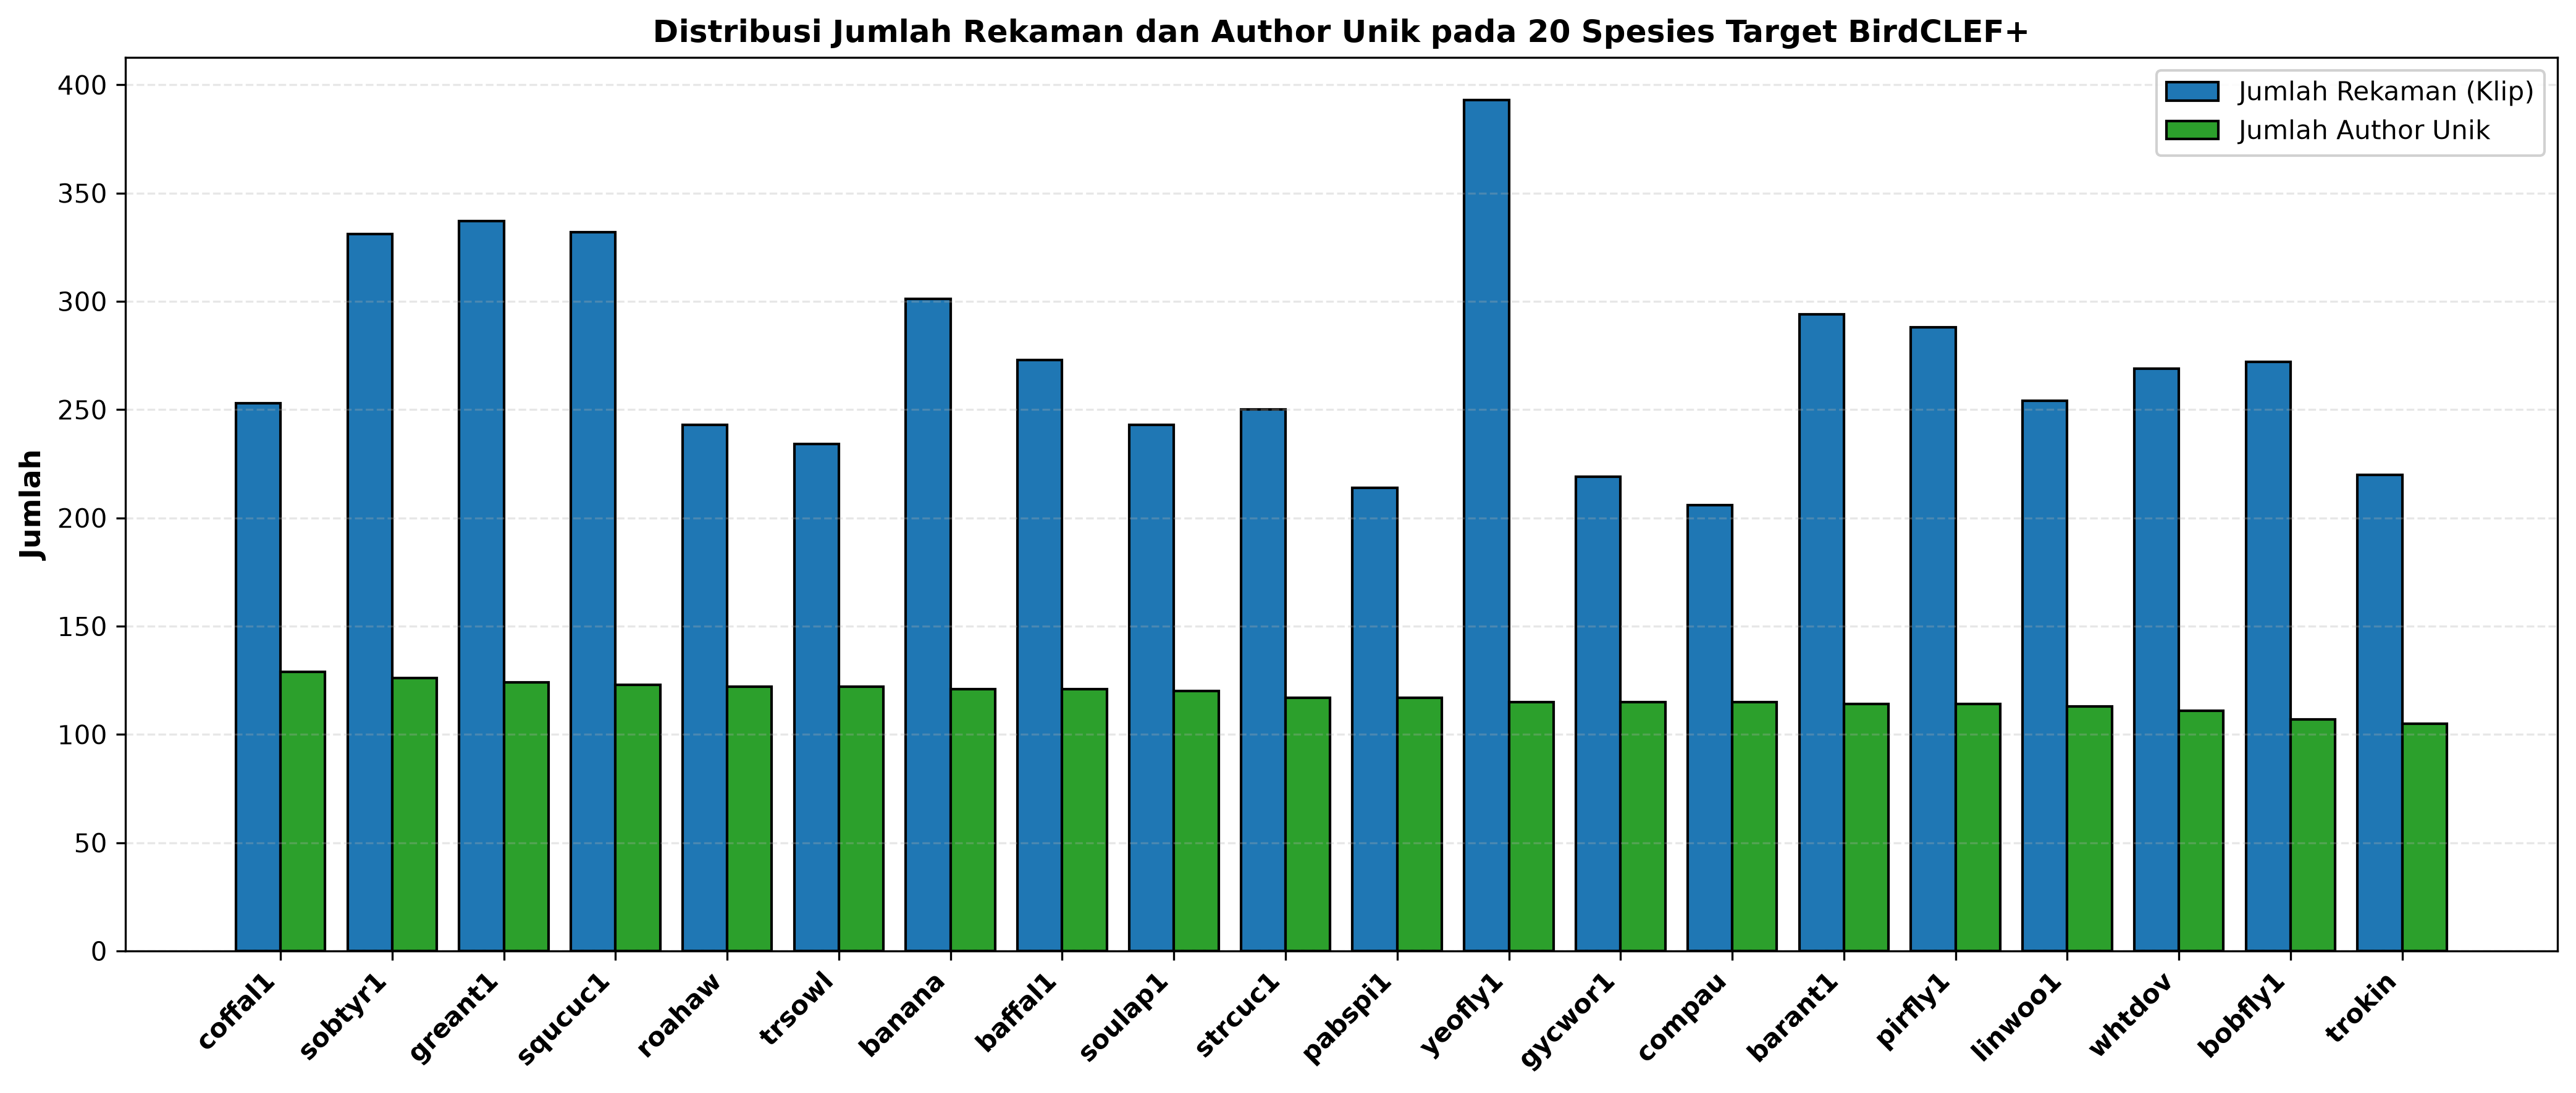

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6), dpi=300)

x = np.arange(len(df_freeze))
width = 0.4

rects1 = ax1.bar(x - width/2, df_freeze["n_klip"], width, label="Jumlah Rekaman (Klip)", color="#1f77b4", edgecolor="black")
rects2 = ax1.bar(x + width/2, df_freeze["n_author"], width, label="Jumlah Author Unik", color="#2ca02c", edgecolor="black")

ax1.set_ylabel("Jumlah", fontweight="bold", fontsize=11)
ax1.set_title("Distribusi Jumlah Rekaman dan Author Unik pada 20 Spesies Target BirdCLEF+", fontweight="bold", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_freeze["species_key"], rotation=45, ha="right", fontweight="bold")
ax1.legend(framealpha=0.9)
ax1.grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "eda_target_species_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

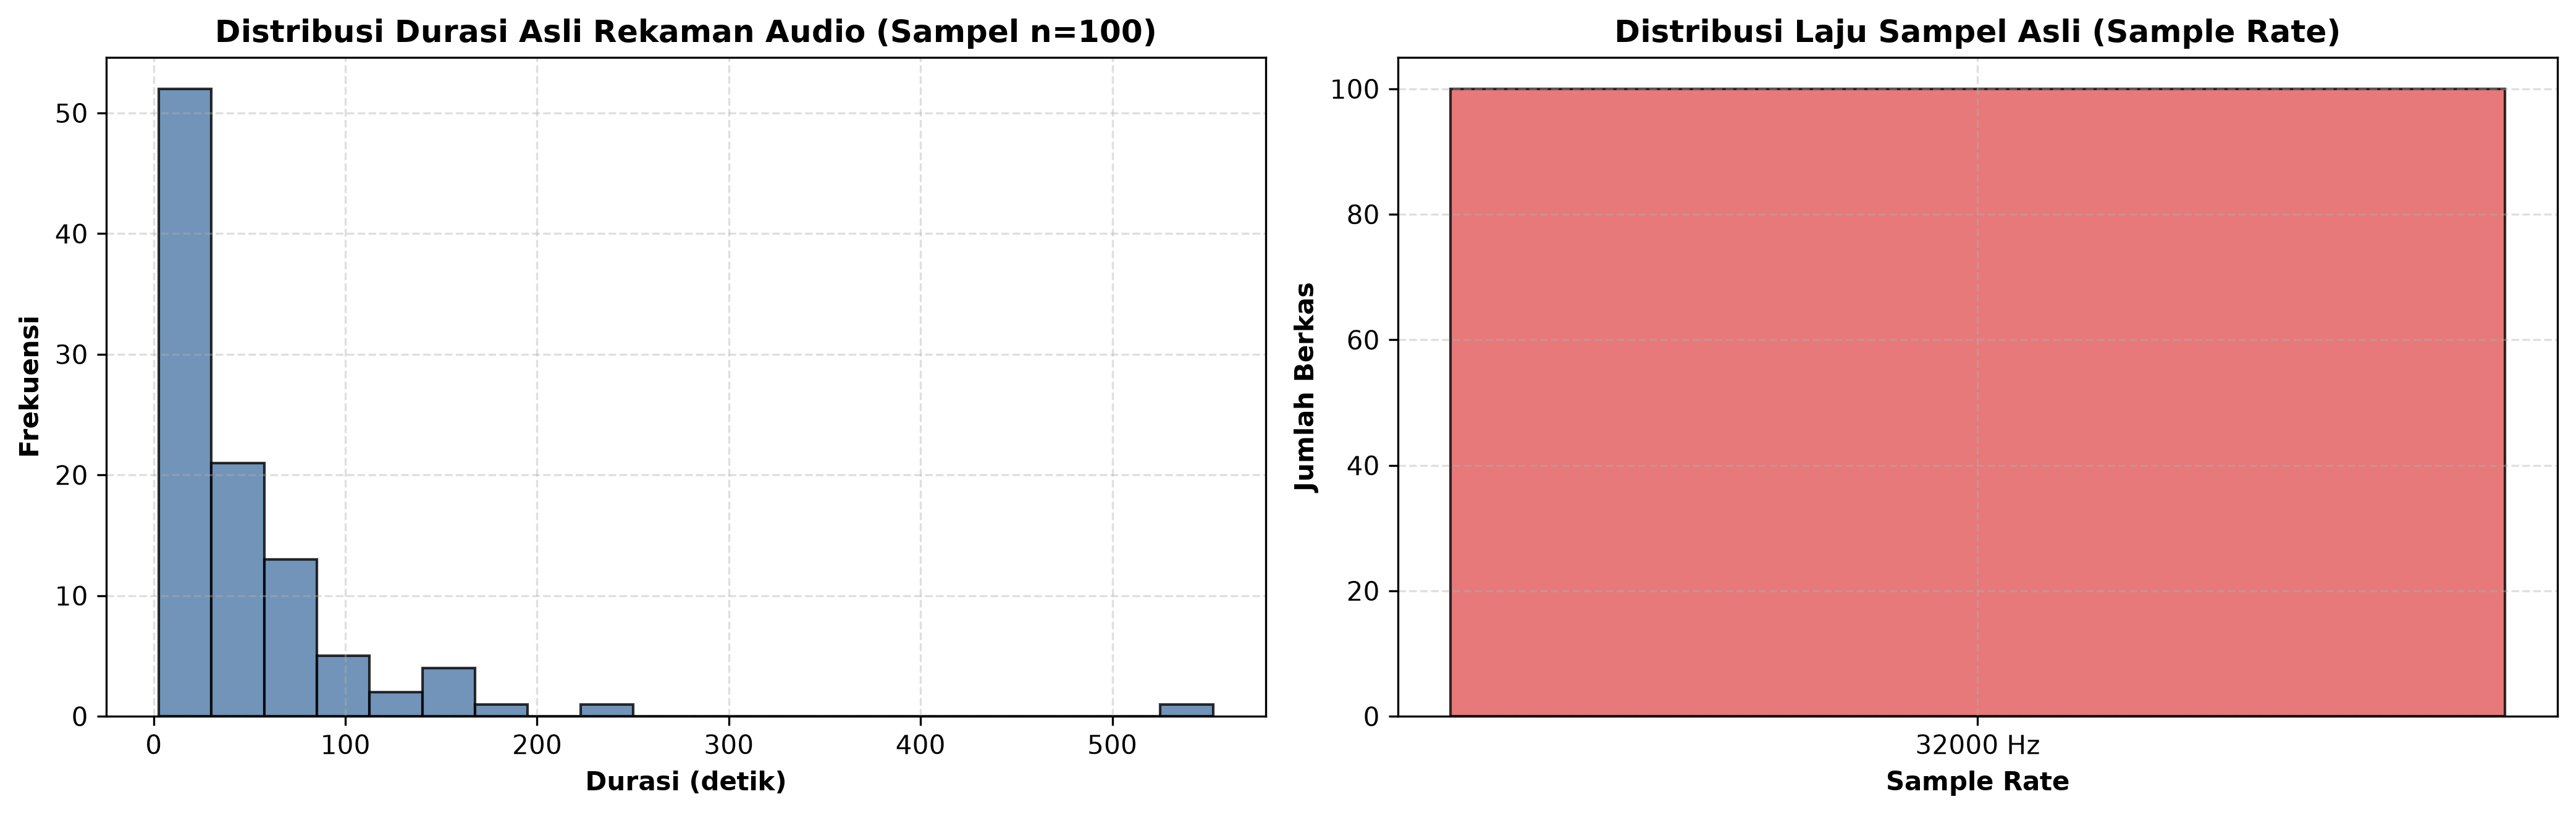

Statistik Durasi Rekaman Asli (detik):
count    100.000000
mean      48.015931
std       66.568757
min        2.690000
25%       13.113469
50%       26.762031
75%       61.035109
max      552.576000
Name: duration_sec, dtype: float64


In [5]:
target_keys = set(df_freeze["species_key"])
df_target_files = df_train[df_train["primary_label"].isin(target_keys) & (df_train["collection"] == "XC")].copy()

# Ambil sampel 100 berkas audio acak untuk audit properti fisik sinyal
sample_files = df_target_files.sample(n=min(100, len(df_target_files)), random_state=42)

durations = []
sample_rates = []

for _, row in sample_files.iterrows():
    audio_path = DATA_DIR / "train_audio" / row["filename"]
    if audio_path.exists():
        info = sf.info(str(audio_path))
        durations.append(info.duration)
        sample_rates.append(info.samplerate)

df_audio_props = pd.DataFrame({"duration_sec": durations, "sample_rate": sample_rates})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), dpi=300)

# Histogram Durasi
ax1.hist(df_audio_props["duration_sec"], bins=20, color="#4e79a7", edgecolor="black", alpha=0.8)
ax1.set_title("Distribusi Durasi Asli Rekaman Audio (Sampel n=100)", fontweight="bold")
ax1.set_xlabel("Durasi (detik)", fontweight="bold")
ax1.set_ylabel("Frekuensi", fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.4)

# Bar Chart Laju Sampel
sr_counts = df_audio_props["sample_rate"].value_counts()
ax2.bar([str(s) + " Hz" for s in sr_counts.index], sr_counts.values, color="#e15759", edgecolor="black", alpha=0.8)
ax2.set_title("Distribusi Laju Sampel Asli (Sample Rate)", fontweight="bold")
ax2.set_xlabel("Sample Rate", fontweight="bold")
ax2.set_ylabel("Jumlah Berkas", fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "eda_audio_physical_properties.png", dpi=300, bbox_inches="tight")
plt.show()

print("Statistik Durasi Rekaman Asli (detik):")
print(df_audio_props["duration_sec"].describe())

c:\Users\Fabio\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


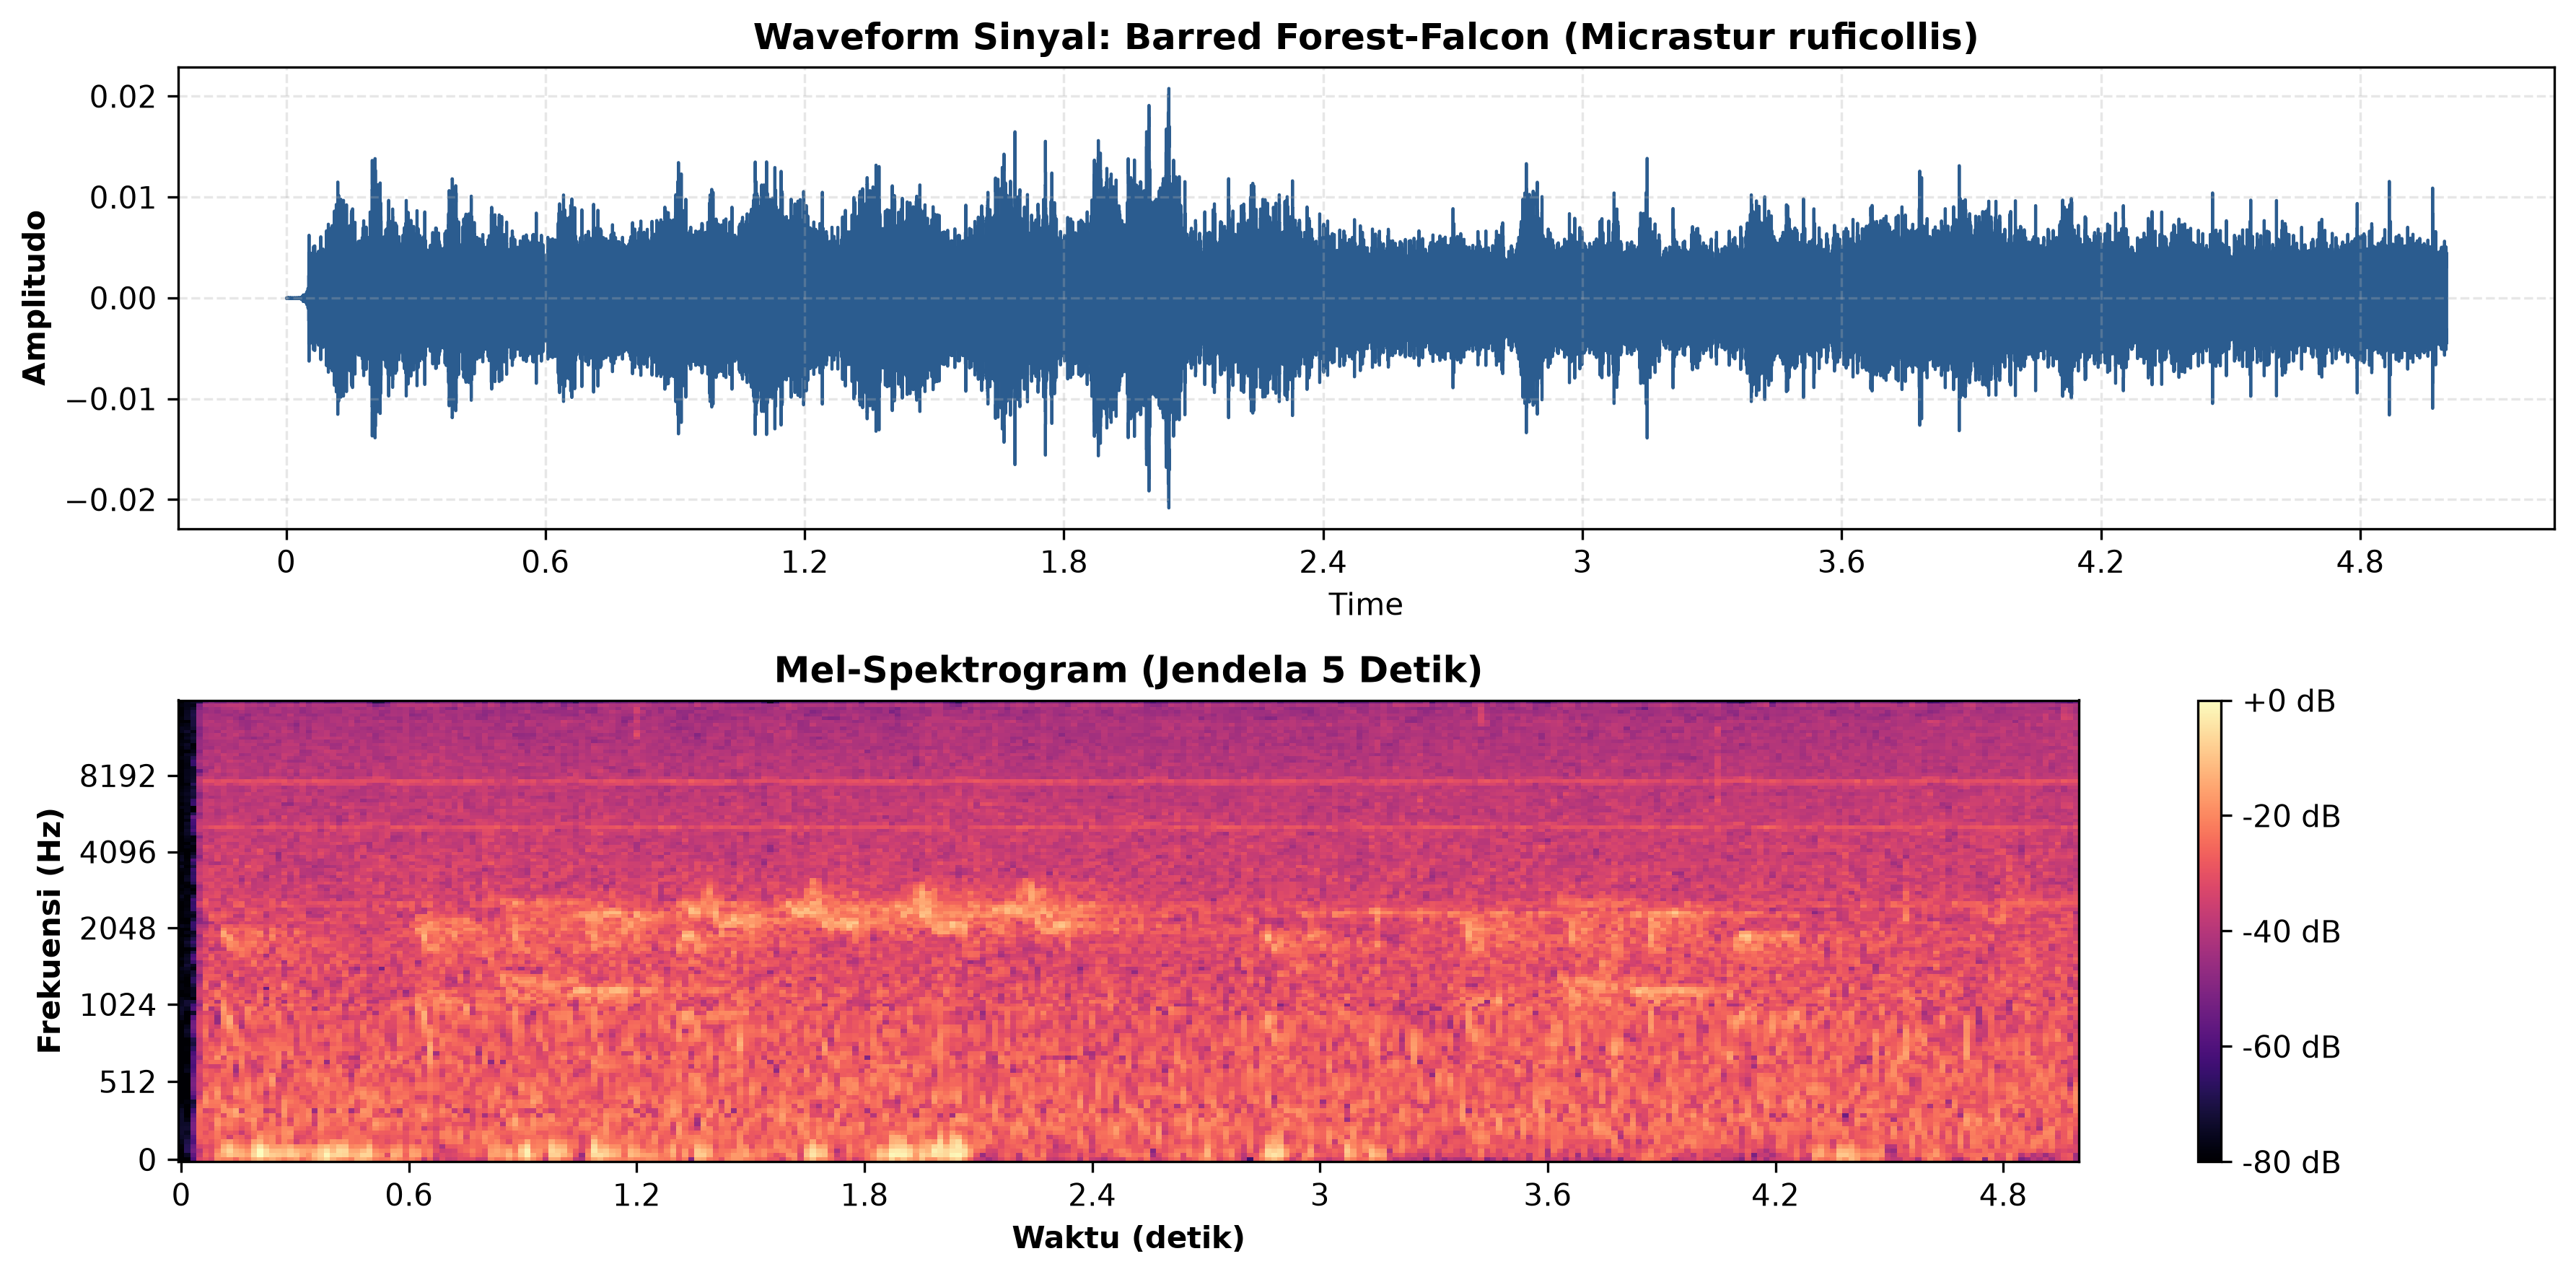

In [6]:
# Pilih 1 berkas representatif dari spesies pertama
sample_row = df_target_files.iloc[0]
sample_path = DATA_DIR / "train_audio" / sample_row["filename"]

y, sr = librosa.load(str(sample_path), sr=None)

# Potong 5 detik pertama untuk inspeksi visual
y_segment = y[:int(sr * 5.0)] if len(y) >= int(sr * 5.0) else y
mel_spec = librosa.feature.melspectrogram(y=y_segment, sr=sr, n_fft=1024, hop_length=512, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), dpi=300)

# Waveform
librosa.display.waveshow(y_segment, sr=sr, ax=ax1, color="#2b5c8f")
ax1.set_title(f"Waveform Sinyal: {sample_row['common_name']} ({sample_row['scientific_name']})", fontweight="bold")
ax1.set_ylabel("Amplitudo", fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.3)

# Mel-Spektrogram
img = librosa.display.specshow(mel_spec_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel", ax=ax2, cmap="magma")
ax2.set_title("Mel-Spektrogram (Jendela 5 Detik)", fontweight="bold")
ax2.set_xlabel("Waktu (detik)", fontweight="bold")
ax2.set_ylabel("Frekuensi (Hz)", fontweight="bold")
fig.colorbar(img, ax=ax2, format="%+2.0f dB")

plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "eda_sample_spectrogram.png", dpi=300, bbox_inches="tight")
plt.show()

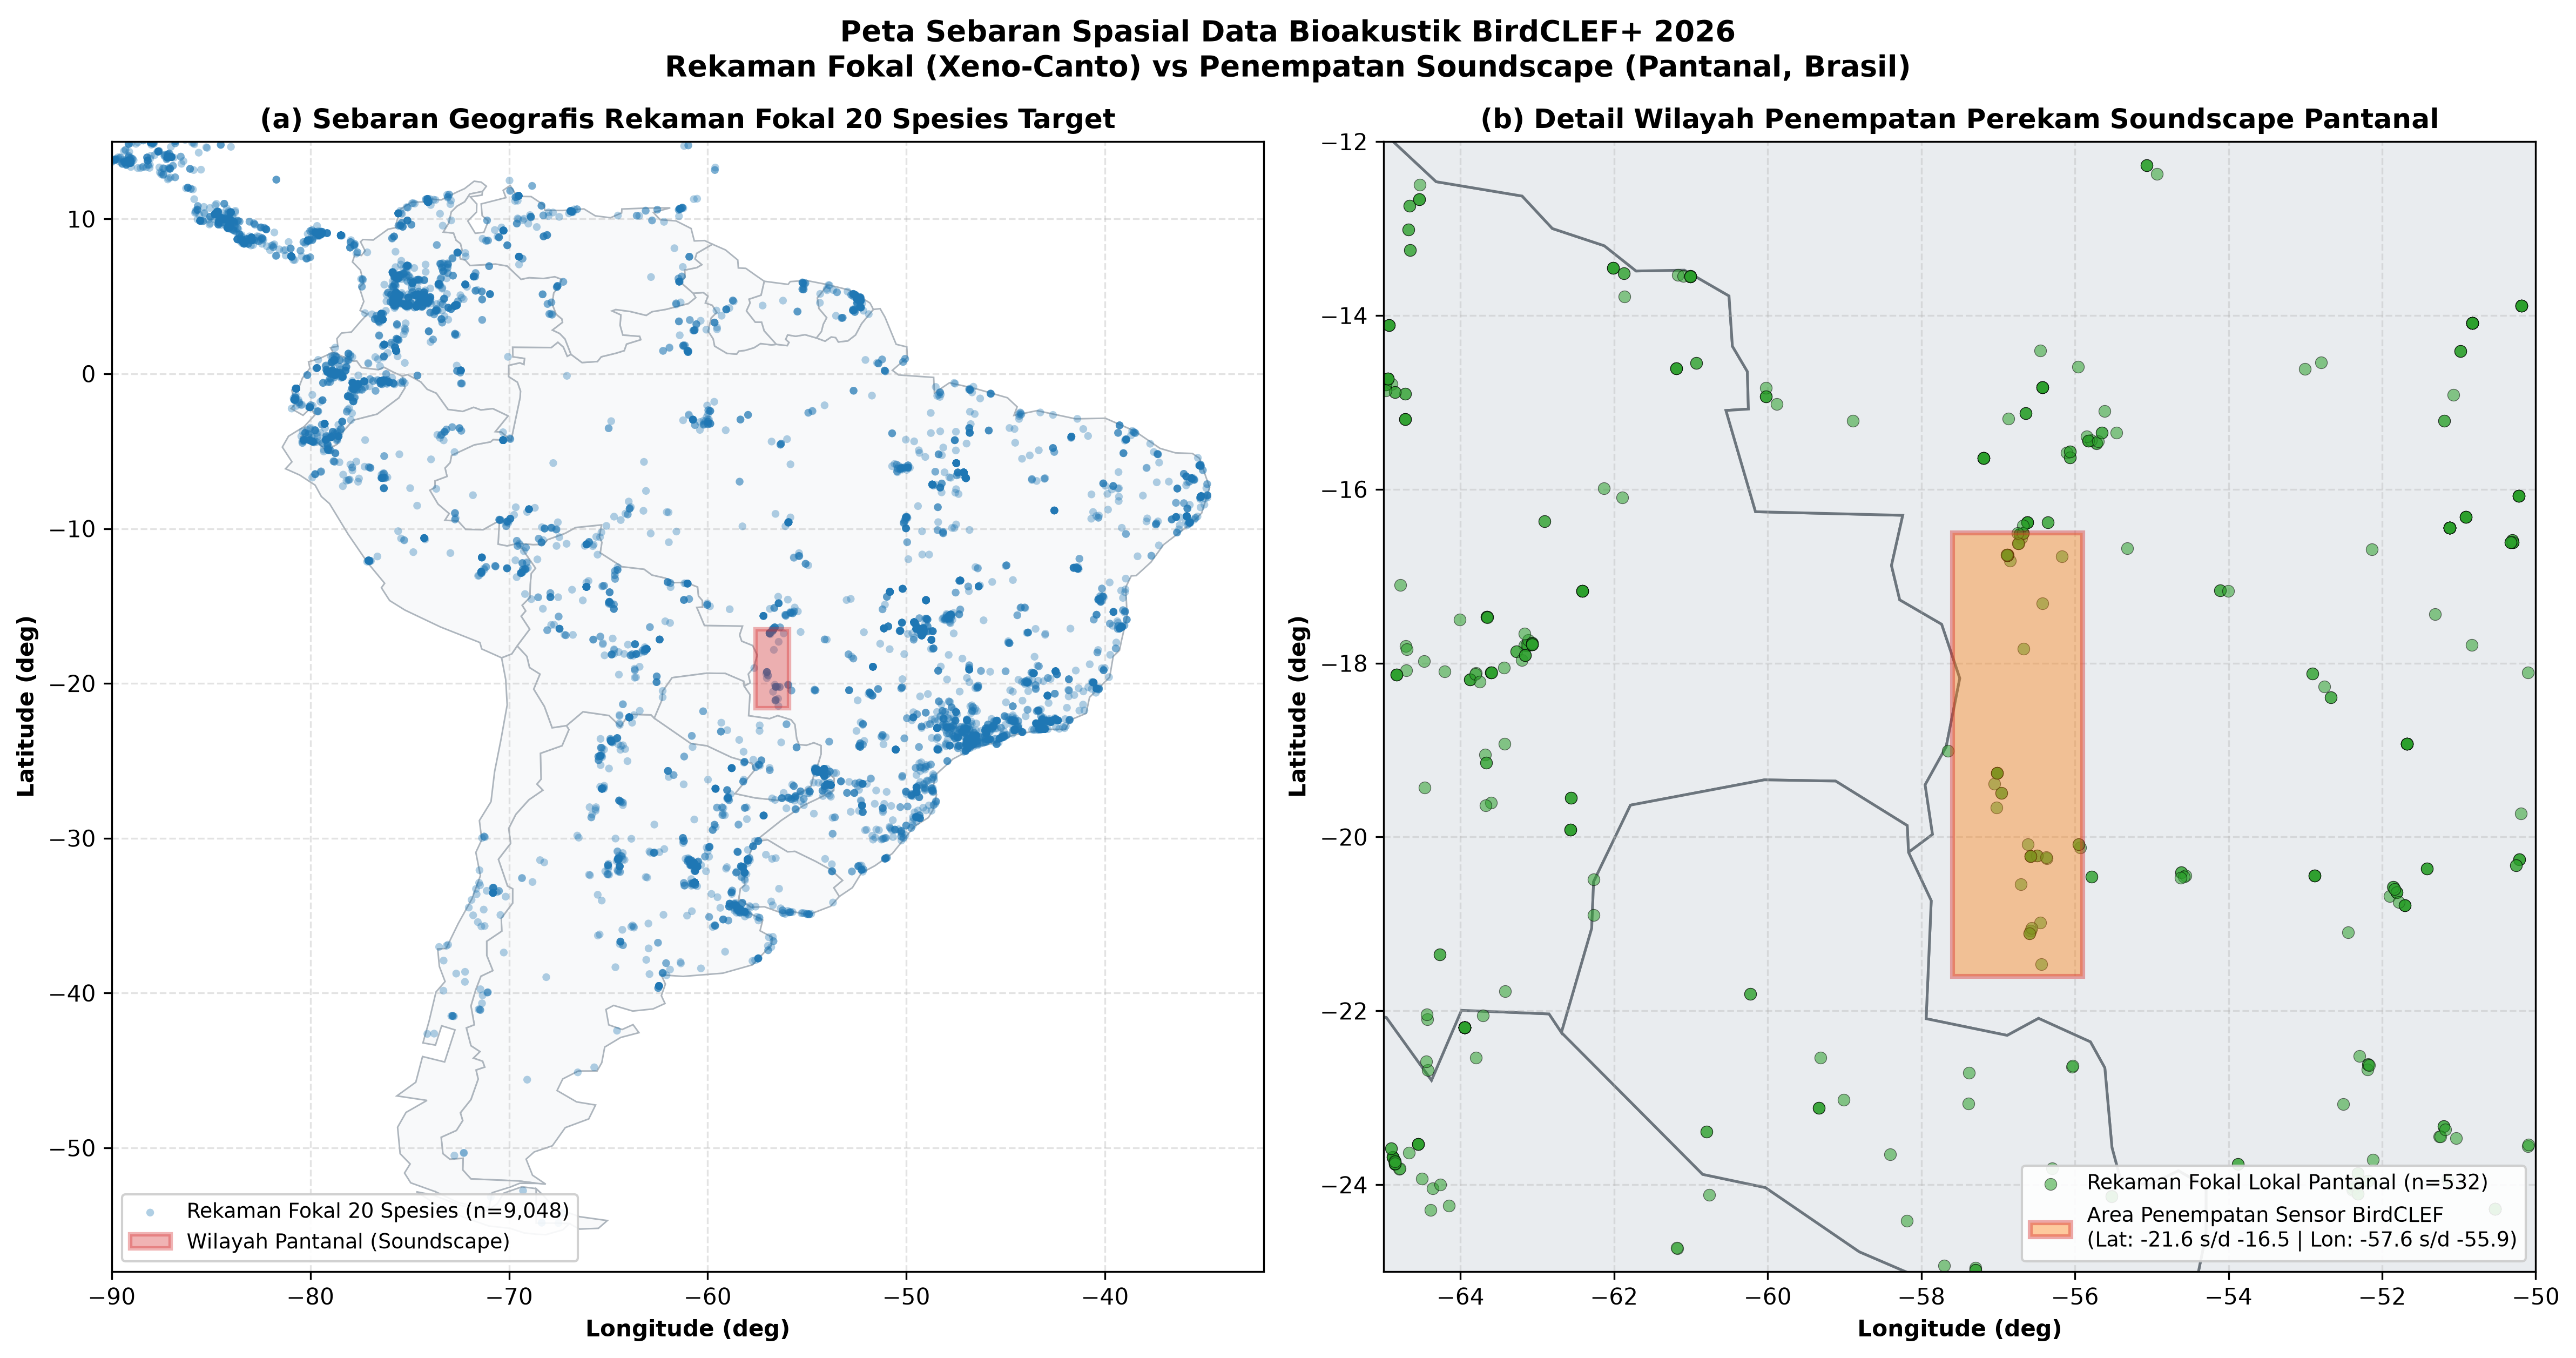

[+] Peta berhasil disimpan ke:
    - d:\FILE AND TASK\TA\results\figures\birdclef_geospatial_distribution_map.png
    - d:\FILE AND TASK\TA\paper\figures\birdclef_geospatial_distribution_map.png


In [7]:
GEOJSON_FILE = MANIFEST_DIR / "south_america.geojson"
df_coords = df_train[df_train["primary_label"].isin(target_keys)].dropna(subset=["latitude", "longitude"]).copy()

# Unduh / Buka GeoJSON poligon batas negara Amerika Selatan
if not GEOJSON_FILE.exists():
    print("[*] Mengunduh GeoJSON batas negara Amerika Selatan...")
    url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=15) as resp:
        world_geo = json.loads(resp.read().decode())
    sa_names = {"Brazil", "Argentina", "Bolivia", "Colombia", "Peru", "Venezuela", "Chile", "Paraguay", "Ecuador", "Guyana", "Uruguay", "Suriname", "French Guiana"}
    sa_features = [f for f in world_geo["features"] if f["properties"]["name"] in sa_names]
    geo_data = {"type": "FeatureCollection", "features": sa_features}
    with open(GEOJSON_FILE, "w", encoding="utf-8") as f:
        json.dump(geo_data, f)
else:
    with open(GEOJSON_FILE, "r", encoding="utf-8") as f:
        geo_data = json.load(f)

def draw_polygons(ax, data, facecolor="#f8f9fa", edgecolor="#adb5bd", lw=0.7):
    for feat in data["features"]:
        geom = feat["geometry"]
        coords = geom["coordinates"]
        if geom["type"] == "Polygon":
            for poly in coords:
                ax.add_patch(Polygon(poly, facecolor=facecolor, edgecolor=edgecolor, linewidth=lw, zorder=1))
        elif geom["type"] == "MultiPolygon":
            for mp in coords:
                for poly in mp:
                    ax.add_patch(Polygon(poly, facecolor=facecolor, edgecolor=edgecolor, linewidth=lw, zorder=1))

# Koordinat Bounding Box Pantanal (-21.6 s/d -16.5 Lat, -57.6 s/d -55.9 Lon)
p_lat_min, p_lat_max = -21.6, -16.5
p_lon_min, p_lon_max = -57.6, -55.9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8.5), dpi=300)

# Panel 1: Makro (Amerika Selatan)
draw_polygons(ax1, geo_data, facecolor="#f8f9fa", edgecolor="#adb5bd", lw=0.7)
ax1.scatter(df_coords["longitude"], df_coords["latitude"], c="#1f77b4", alpha=0.35, s=12, edgecolors="none", zorder=2, label=f"Rekaman Fokal 20 Spesies (n={len(df_coords):,})")
rect_macro = Rectangle((p_lon_min, p_lat_min), p_lon_max - p_lon_min, p_lat_max - p_lat_min, linewidth=2.0, edgecolor="#d62728", facecolor="#d62728", alpha=0.35, zorder=3, label="Wilayah Pantanal (Soundscape)")
ax1.add_patch(rect_macro)
ax1.set_xlim(-90, -32)
ax1.set_ylim(-58, 15)
ax1.set_xlabel("Longitude (deg)", fontweight="bold")
ax1.set_ylabel("Latitude (deg)", fontweight="bold")
ax1.set_title("(a) Sebaran Geografis Rekaman Fokal 20 Spesies Target", fontweight="bold")
ax1.legend(loc="lower left", framealpha=0.9, fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.35)

# Panel 2: Mikro (Pantanal Focus)
draw_polygons(ax2, geo_data, facecolor="#e9ecef", edgecolor="#6c757d", lw=1.2)
df_pantanal = df_coords[(df_coords["longitude"] >= -65.0) & (df_coords["longitude"] <= -50.0) & (df_coords["latitude"] >= -25.0) & (df_coords["latitude"] <= -12.0)]
ax2.scatter(df_pantanal["longitude"], df_pantanal["latitude"], c="#2ca02c", alpha=0.55, s=28, edgecolors="black", linewidth=0.3, zorder=2, label=f"Rekaman Fokal Lokal Pantanal (n={len(df_pantanal):,})")
rect_micro = Rectangle((p_lon_min, p_lat_min), p_lon_max - p_lon_min, p_lat_max - p_lat_min, linewidth=2.2, edgecolor="#d62728", facecolor="#ff7f0e", alpha=0.4, zorder=3, label="Area Penempatan Sensor BirdCLEF\n(Lat: -21.6 s/d -16.5 | Lon: -57.6 s/d -55.9)")
ax2.add_patch(rect_micro)
ax2.set_xlim(-65, -50)
ax2.set_ylim(-25, -12)
ax2.set_xlabel("Longitude (deg)", fontweight="bold")
ax2.set_ylabel("Latitude (deg)", fontweight="bold")
ax2.set_title("(b) Detail Wilayah Penempatan Perekam Soundscape Pantanal", fontweight="bold")
ax2.legend(loc="lower right", framealpha=0.9, fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.35)

plt.suptitle("Peta Sebaran Spasial Data Bioakustik BirdCLEF+ 2026\nRekaman Fokal (Xeno-Canto) vs Penempatan Soundscape (Pantanal, Brasil)", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()

map_out1 = RESULTS_FIG_DIR / "birdclef_geospatial_distribution_map.png"
map_out2 = PAPER_FIG_DIR / "birdclef_geospatial_distribution_map.png"
plt.savefig(map_out1, bbox_inches="tight", dpi=300)
plt.savefig(map_out2, bbox_inches="tight", dpi=300)
plt.show()

print(f"[+] Peta berhasil disimpan ke:\n    - {map_out1}\n    - {map_out2}")